# PyTorch FNN Regression — 은닉층 노드 수 비교

이 노트북은 모든 은닉층의 노드 수를 동일하게 유지한 채 **8 → 1**로 줄여가며 FNN 회귀 성능과 모델 복잡도를 비교합니다.

- 입력: `data1`
- 출력: `data2`
- 은닉층 수: 3개로 고정
- 은닉층 너비: `8, 7, 6, ..., 1`
- 기본 평가: 고정된 80:20 holdout 분할의 Test R², RMSE, MAE, MSE
- 요청 플롯: x축=노드 수, 왼쪽 y축=Test R², 오른쪽 y축=학습 가능한 파라미터 수
- 모델 저장: `fnn_model_nodes_8.pt`부터 `fnn_model_nodes_1.pt`까지

각 `.pt` 체크포인트에는 모델 가중치뿐 아니라 구조, 스케일러 통계, 평가 지표도 함께 저장됩니다. 모델을 고를 때는 Test R²가 높고 RMSE가 낮은 모델을 우선 확인하세요.


In [1]:
# 1. 라이브러리 및 데이터 저장소 준비

import os
import random
import copy
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Colab과 로컬 Jupyter에서 모두 실행 가능하게 경로를 선택합니다.
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
if IN_COLAB:
    REPO_ROOT = '/content/Basic_example_copy'

    if not os.path.exists(REPO_ROOT):
        subprocess.run(
            [
                'git', 'clone', '-q',
                'https://github.com/Jaehoon-Shim/Basic_example.git',
                REPO_ROOT,
            ],
            check=True,
        )
else:
    REPO_ROOT = os.path.abspath('.')
os.makedirs(os.path.join(REPO_ROOT, 'data'), exist_ok=True)
os.makedirs(os.path.join(REPO_ROOT, 'results'), exist_ok=True)
print('Environment:', 'Google Colab' if IN_COLAB else 'Local Jupyter')
print('Repository :', REPO_ROOT)


Environment: Local Jupyter
Repository : c:\Users\HP\Documents\Github\Basic_example


In [2]:
# 2. 실험 설정

SEED = 42
EPOCHS = 2800
LEARNING_RATE = 1e-3
PRINT_INTERVAL = 500

# 모든 은닉층은 같은 너비를 사용하며, 은닉층 개수는 기존과 동일한 3개입니다.
HIDDEN_NODE_OPTIONS = list(range(8, 0, -1))
N_HIDDEN_LAYERS = 3

# 모델 선택을 위한 기본 설정: 모든 모델에 똑같은 80:20 분할을 적용합니다.
USE_HOLDOUT_SPLIT = True
TEST_SIZE = 0.20

BASE_DIR = REPO_ROOT
RESULT_DIR = os.path.join(BASE_DIR, 'results', 'node_sweep')
MODEL_DIR = os.path.join(RESULT_DIR, 'models')
CSV_PATH = os.path.join(BASE_DIR, 'data', 'test.csv')

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

set_global_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device       :', DEVICE)
print('CSV Path     :', CSV_PATH)
print('Result Dir   :', RESULT_DIR)
print('Node options :', HIDDEN_NODE_OPTIONS)
print('Hidden layers:', N_HIDDEN_LAYERS)
print('CSV Exists   :', os.path.exists(CSV_PATH))


Device       : cpu
CSV Path     : c:\Users\HP\Documents\Github\Basic_example\data\test.csv
Result Dir   : c:\Users\HP\Documents\Github\Basic_example\results\node_sweep
Node options : [8, 7, 6, 5, 4, 3, 2, 1]
Hidden layers: 3
CSV Exists   : True


In [3]:
# 3. CSV 로드 및 전처리

df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]

required_columns = ['data1', 'data2']
if not all(col in df.columns for col in required_columns):
    raise ValueError(
        f'CSV에 {required_columns} 열이 필요합니다. '
        f'현재 열: {df.columns.tolist()}'
    )

df = df[required_columns].copy()
df['data1'] = pd.to_numeric(df['data1'], errors='coerce')
df['data2'] = pd.to_numeric(df['data2'], errors='coerce')
df = df.dropna().reset_index(drop=True)

print('Data shape:', df.shape)
display(df.head())
display(df.describe())


Data shape: (400, 2)


,data1,data2
0,0.000000,7.438766
1,0.100251,7.311275
2,0.200501,7.496599
3,0.300752,7.701600
4,0.401003,7.327267


,data1,data2
count,400.000000,400.000000
mean,20.000000,5.441844
std,11.590406,3.665019
min,0.000000,0.200000
25%,10.000000,2.509633
50%,20.000000,4.464003
75%,30.000000,7.972711
max,40.000000,16.573641


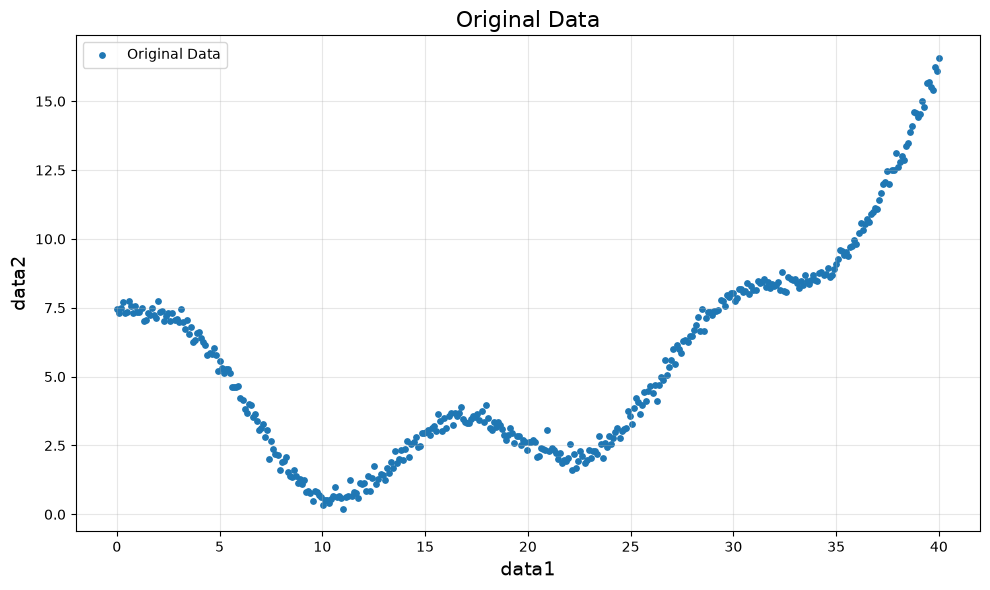

Saved: c:\Users\HP\Documents\Github\Basic_example\results\node_sweep\original_data.jpg


In [4]:
# 4. 원본 데이터 확인

plt.figure(figsize=(10, 6))
plt.scatter(df['data1'], df['data2'], s=15, label='Original Data')
plt.xlabel('data1', fontsize=14)
plt.ylabel('data2', fontsize=14)
plt.title('Original Data', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

original_data_path = os.path.join(RESULT_DIR, 'original_data.jpg')
plt.savefig(original_data_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', original_data_path)


In [5]:
# 5. 모든 모델에 공통으로 사용할 Train/Test 분할과 표준화

X = df[['data1']].to_numpy(dtype=np.float32)
y = df[['data2']].to_numpy(dtype=np.float32)

if USE_HOLDOUT_SPLIT:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=SEED,
        shuffle=True,
    )
else:
    # 기존 노트북처럼 동일 데이터를 평가하려면 USE_HOLDOUT_SPLIT=False로 바꾸세요.
    X_train, y_train = X.copy(), y.copy()
    X_test, y_test = X.copy(), y.copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)
X_test_scaled = x_scaler.transform(X_test).astype(np.float32)
y_test_scaled = y_scaler.transform(y_test).astype(np.float32)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=DEVICE)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=DEVICE)

print('X_train:', X_train_tensor.shape)
print('X_test :', X_test_tensor.shape)
print('Split  :', '80:20 holdout' if USE_HOLDOUT_SPLIT else 'Train = Test')


X_train: torch.Size([320, 1])
X_test : torch.Size([80, 1])
Split  : 80:20 holdout


In [6]:
# 6. 노드 수를 인자로 받는 FNN 모델과 평가 함수

class FNNRegressor(nn.Module):
    def __init__(
        self,
        hidden_nodes,
        hidden_layers=N_HIDDEN_LAYERS,
        input_dim=1,
        output_dim=1,
    ):
        super().__init__()

        layers = [nn.Linear(input_dim, hidden_nodes), nn.ReLU()]
        for _ in range(hidden_layers - 1):
            layers.extend([
                nn.Linear(hidden_nodes, hidden_nodes),
                nn.ReLU(),
            ])
        layers.append(nn.Linear(hidden_nodes, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    return {
        'mse': float(mse),
        'rmse': float(np.sqrt(mse)),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


for nodes in HIDDEN_NODE_OPTIONS:
    sample_model = FNNRegressor(nodes)
    print(
        f'nodes={nodes}: '
        f'{count_trainable_parameters(sample_model):,} trainable parameters'
    )


nodes=8: 169 trainable parameters
nodes=7: 134 trainable parameters
nodes=6: 103 trainable parameters
nodes=5: 76 trainable parameters
nodes=4: 53 trainable parameters
nodes=3: 34 trainable parameters
nodes=2: 19 trainable parameters
nodes=1: 8 trainable parameters


In [7]:
# 7. 한 가지 노드 수를 학습하고 체크포인트를 저장하는 함수

def train_and_save_model(hidden_nodes):
    # 각 모델을 같은 seed에서 시작해 비교를 재현 가능하게 만듭니다.
    set_global_seed(SEED)

    model = FNNRegressor(
        hidden_nodes=hidden_nodes,
        hidden_layers=N_HIDDEN_LAYERS,
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=100,
    )

    train_loss_history = []
    test_loss_history = []
    best_test_loss = float('inf')
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        optimizer.zero_grad()

        train_pred = model(X_train_tensor)
        train_loss = criterion(train_pred, y_train_tensor)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_tensor)
            test_loss = criterion(test_pred, y_test_tensor)

        train_loss_value = float(train_loss.item())
        test_loss_value = float(test_loss.item())
        train_loss_history.append(train_loss_value)
        test_loss_history.append(test_loss_value)
        scheduler.step(test_loss_value)

        if test_loss_value < best_test_loss:
            best_test_loss = test_loss_value
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % PRINT_INTERVAL == 0 or epoch == EPOCHS:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f'[nodes={hidden_nodes}] {epoch:4d}/{EPOCHS} | '
                f'Train={train_loss_value:.8f} | '
                f'Test={test_loss_value:.8f} | '
                f'LR={current_lr:.6g}'
            )

    model.load_state_dict(best_model_state)
    model.eval()

    with torch.no_grad():
        train_pred_scaled = model(X_train_tensor).cpu().numpy()
        test_pred_scaled = model(X_test_tensor).cpu().numpy()

    train_pred = y_scaler.inverse_transform(train_pred_scaled)
    test_pred = y_scaler.inverse_transform(test_pred_scaled)
    train_scores = regression_metrics(y_train, train_pred)
    test_scores = regression_metrics(y_test, test_pred)
    parameter_count = count_trainable_parameters(model)

    model_filename = f'fnn_model_nodes_{hidden_nodes}.pt'
    model_path = os.path.join(MODEL_DIR, model_filename)

    checkpoint = {
        'model_state_dict': {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
        },
        'hidden_nodes': int(hidden_nodes),
        'hidden_layers': int(N_HIDDEN_LAYERS),
        'input_dim': 1,
        'output_dim': 1,
        'parameter_count': int(parameter_count),
        'best_epoch': int(best_epoch),
        'best_test_loss_scaled': float(best_test_loss),
        'train_metrics': train_scores,
        'test_metrics': test_scores,
        'x_scaler': {
            'mean': x_scaler.mean_.astype(np.float32).tolist(),
            'scale': x_scaler.scale_.astype(np.float32).tolist(),
            'var': x_scaler.var_.astype(np.float32).tolist(),
        },
        'y_scaler': {
            'mean': y_scaler.mean_.astype(np.float32).tolist(),
            'scale': y_scaler.scale_.astype(np.float32).tolist(),
            'var': y_scaler.var_.astype(np.float32).tolist(),
        },
        'seed': int(SEED),
        'epochs': int(EPOCHS),
        'learning_rate': float(LEARNING_RATE),
        'use_holdout_split': bool(USE_HOLDOUT_SPLIT),
        'test_size': float(TEST_SIZE),
    }
    torch.save(checkpoint, model_path)

    history = pd.DataFrame({
        'hidden_nodes': hidden_nodes,
        'epoch': np.arange(1, EPOCHS + 1),
        'train_loss_scaled': train_loss_history,
        'test_loss_scaled': test_loss_history,
    })

    result = {
        'hidden_nodes': hidden_nodes,
        'hidden_layers': N_HIDDEN_LAYERS,
        'parameter_count': parameter_count,
        'best_epoch': best_epoch,
        'best_test_loss_scaled': best_test_loss,
        **{f'train_{k}': v for k, v in train_scores.items()},
        **{f'test_{k}': v for k, v in test_scores.items()},
        'model_filename': model_filename,
        'model_path': model_path,
    }

    print(
        f'Saved {model_filename} | params={parameter_count:,} | '
        f'Test R²={test_scores["r2"]:.6f} | '
        f'Test RMSE={test_scores["rmse"]:.6f}'
    )
    return result, history


In [8]:
# 8. 노드 수 8 → 1 전체 실험 실행 및 모델 저장

all_results = []
all_histories = []

for hidden_nodes in HIDDEN_NODE_OPTIONS:
    print('\n' + '=' * 72)
    print(f'Training model with {hidden_nodes} nodes in every hidden layer')
    print('=' * 72)

    result, history = train_and_save_model(hidden_nodes)
    all_results.append(result)
    all_histories.append(history)

comparison_df = pd.DataFrame(all_results).sort_values(
    'hidden_nodes', ascending=False
).reset_index(drop=True)
history_df = pd.concat(all_histories, ignore_index=True)

comparison_csv_path = os.path.join(RESULT_DIR, 'node_width_comparison.csv')
history_csv_path = os.path.join(RESULT_DIR, 'node_width_training_history.csv')

comparison_df.to_csv(comparison_csv_path, index=False)
history_df.to_csv(history_csv_path, index=False)

print('\nSaved:', comparison_csv_path)
print('Saved:', history_csv_path)
print('Saved model count:', len(list(filter(lambda n: n.endswith('.pt'), os.listdir(MODEL_DIR)))))



Training model with 8 nodes in every hidden layer
[nodes=8]    1/2800 | Train=0.96777850 | Test=1.30057526 | LR=0.001
[nodes=8]  500/2800 | Train=0.05868971 | Test=0.06077795 | LR=0.001
[nodes=8] 1000/2800 | Train=0.01755112 | Test=0.01350104 | LR=0.001
[nodes=8] 1500/2800 | Train=0.00389214 | Test=0.00502364 | LR=0.001
[nodes=8] 2000/2800 | Train=0.00365481 | Test=0.00493933 | LR=0.000125
[nodes=8] 2500/2800 | Train=0.00364896 | Test=0.00494000 | LR=3.90625e-06
[nodes=8] 2800/2800 | Train=0.00364873 | Test=0.00493998 | LR=4.88281e-07
Saved fnn_model_nodes_8.pt | params=169 | Test R²=0.996353 | Test RMSE=0.248228

Training model with 7 nodes in every hidden layer
[nodes=7]    1/2800 | Train=1.06841600 | Test=1.38204682 | LR=0.001
[nodes=7]  500/2800 | Train=1.00067735 | Test=1.35392940 | LR=0.00025
[nodes=7] 1000/2800 | Train=1.00037789 | Test=1.35472095 | LR=7.8125e-06
[nodes=7] 1500/2800 | Train=1.00036728 | Test=1.35475576 | LR=2.44141e-07
[nodes=7] 2000/2800 | Train=1.00036693 | T

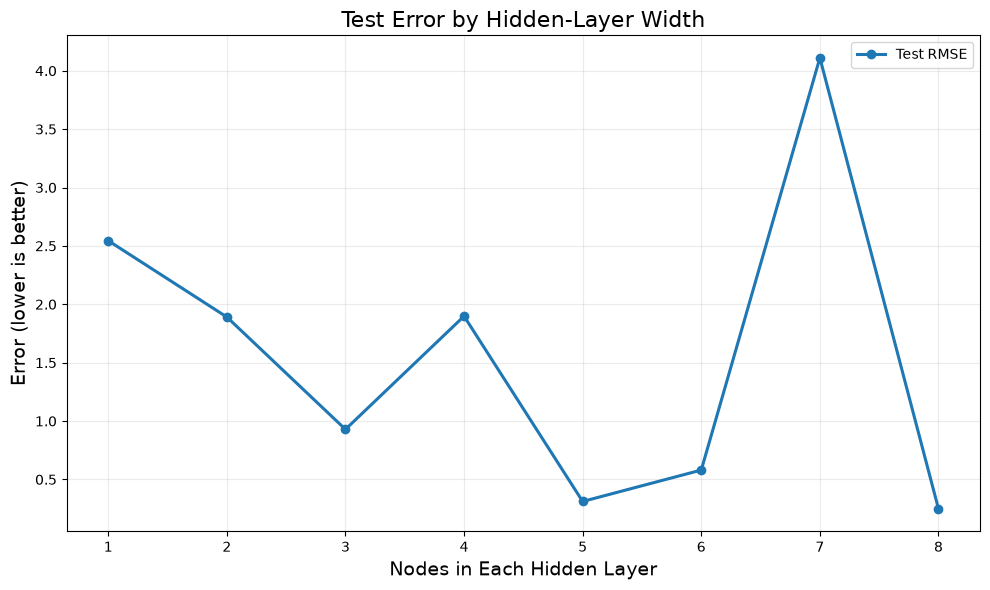

Saved: c:\Users\HP\Documents\Github\Basic_example\results\node_sweep\node_width_test_errors.png


In [9]:
# 11. 보조 플롯: 노드 수에 따른 Test 오차 변화
plot_df = comparison_df.sort_values('hidden_nodes')
x_nodes = plot_df['hidden_nodes'].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_nodes, plot_df['test_rmse'], marker='o', linewidth=2.2, label='Test RMSE')
ax.set_xlabel('Nodes in Each Hidden Layer', fontsize=14)
ax.set_ylabel('Error (lower is better)', fontsize=14)
ax.set_xticks(x_nodes)
ax.set_title('Test Error by Hidden-Layer Width', fontsize=16)
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()

error_plot_path = os.path.join(RESULT_DIR, 'node_width_test_errors.png')
plt.savefig(error_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', error_plot_path)


In [12]:
# 12. 저장된 모델 복원 함수

def restore_standard_scaler(saved_state):
    scaler = StandardScaler()
    scaler.mean_ = np.asarray(saved_state['mean'], dtype=np.float64)
    scaler.scale_ = np.asarray(saved_state['scale'], dtype=np.float64)
    scaler.var_ = np.asarray(saved_state['var'], dtype=np.float64)
    scaler.n_features_in_ = len(scaler.mean_)
    scaler.n_samples_seen_ = 1
    return scaler


def load_saved_fnn(checkpoint_path, device=DEVICE):
    # PyTorch 버전에 따라 weights_only 인자 지원 여부가 달라질 수 있습니다.
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)

    loaded_model = FNNRegressor(
        hidden_nodes=checkpoint['hidden_nodes'],
        hidden_layers=checkpoint['hidden_layers'],
        input_dim=checkpoint['input_dim'],
        output_dim=checkpoint['output_dim'],
    ).to(device)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()

    loaded_x_scaler = restore_standard_scaler(checkpoint['x_scaler'])
    loaded_y_scaler = restore_standard_scaler(checkpoint['y_scaler'])
    return loaded_model, loaded_x_scaler, loaded_y_scaler, checkpoint


BEST_MODEL_PATH = "results/node_sweep/models/fnn_model_nodes_8.pt"
selected_model, selected_x_scaler, selected_y_scaler, selected_checkpoint = load_saved_fnn(
    BEST_MODEL_PATH
)

print('Loaded:', os.path.basename(BEST_MODEL_PATH))
print('Nodes :', selected_checkpoint['hidden_nodes'])
print('Params:', selected_checkpoint['parameter_count'])
print('Metric:', selected_checkpoint['test_metrics'])


Loaded: fnn_model_nodes_8.pt
Nodes : 8
Params: 169
Metric: {'mse': 0.061617303639650345, 'rmse': 0.24822832964762573, 'mae': 0.1873493194580078, 'r2': 0.9963526129722595}


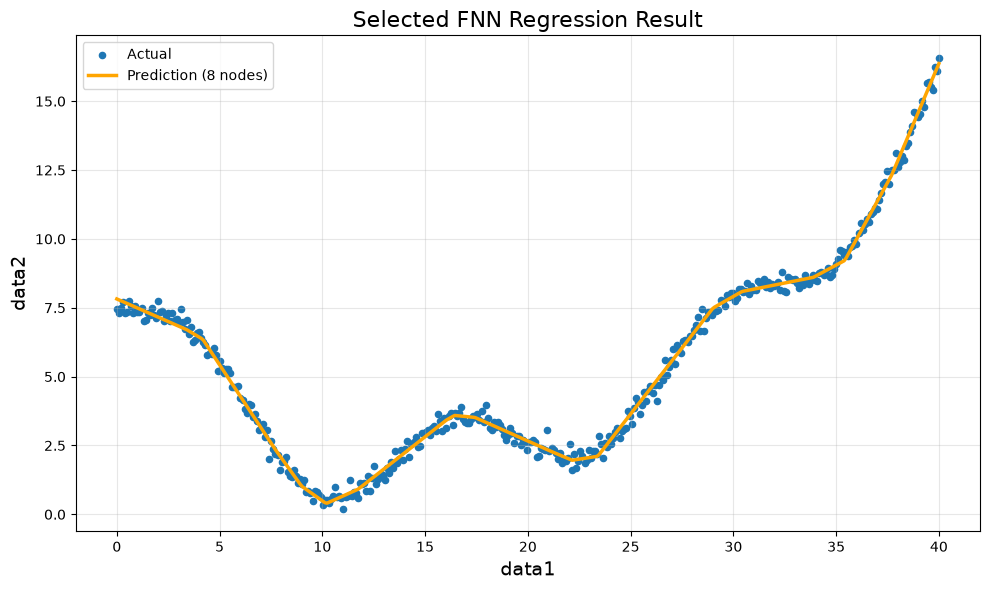

Saved: c:\Users\HP\Documents\Github\Basic_example\results\node_sweep\best_model_nodes_8_prediction.png


In [13]:
# 13. 선택된 최적 모델의 전체 데이터 예측 시각화

X_all_scaled = selected_x_scaler.transform(X).astype(np.float32)
X_all_tensor = torch.tensor(X_all_scaled, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    y_all_pred_scaled = selected_model(X_all_tensor).cpu().numpy()

y_all_pred = selected_y_scaler.inverse_transform(y_all_pred_scaled)
sort_idx = np.argsort(X.flatten())

plt.figure(figsize=(10, 6))
plt.scatter(
    X.flatten()[sort_idx],
    y.flatten()[sort_idx],
    s=20,
    label='Actual',
)
plt.plot(
    X.flatten()[sort_idx],
    y_all_pred.flatten()[sort_idx],
    color='orange',
    linewidth=2.5,
    label=f'Prediction ({selected_checkpoint["hidden_nodes"]} nodes)',
)
plt.xlabel('data1', fontsize=14)
plt.ylabel('data2', fontsize=14)
plt.title('Selected FNN Regression Result', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

best_prediction_plot_path = os.path.join(
    RESULT_DIR,
    f'best_model_nodes_{selected_checkpoint["hidden_nodes"]}_prediction.png',
)
plt.savefig(best_prediction_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', best_prediction_plot_path)
